<a href="https://colab.research.google.com/github/ReddyvariSasidharReddy/student_performance/blob/main/student_result_prediction_Untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [21]:
# Cell 2: Load Dataset
# Download from GitHub (public dataset)
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: (1000, 8)

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
# Cell 3: Data Overview
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Statistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


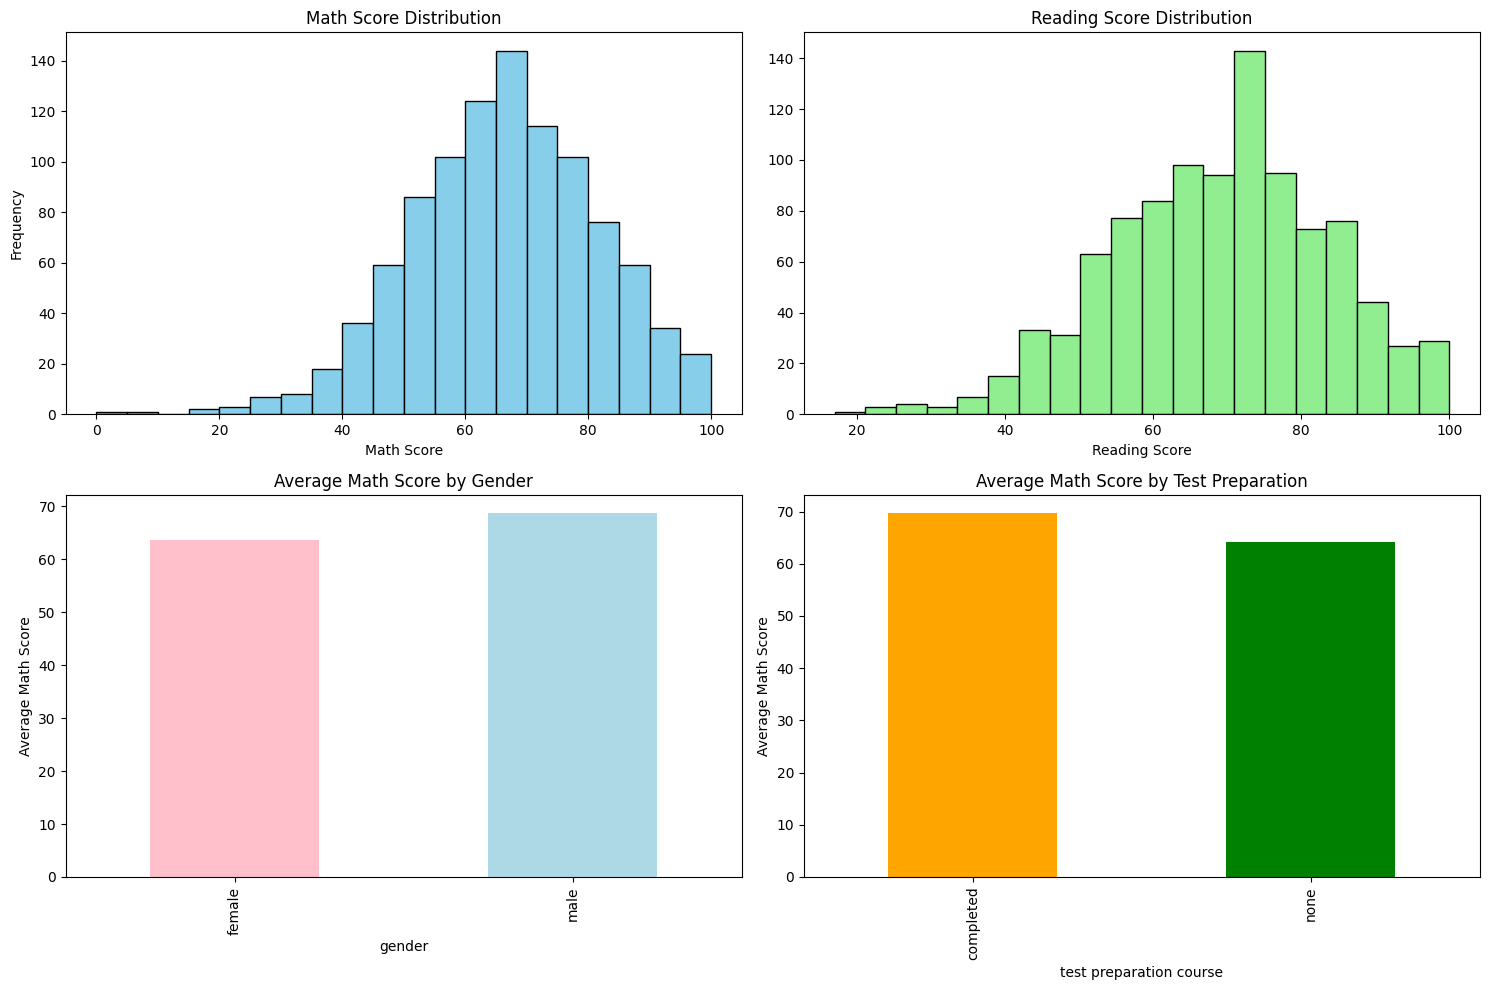

In [23]:
# Cell 4: Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Score distributions
axes[0,0].hist(df['math score'], bins=20, color='skyblue', edgecolor='black')
axes[0,0].set_title('Math Score Distribution')
axes[0,0].set_xlabel('Math Score')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(df['reading score'], bins=20, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Reading Score Distribution')
axes[0,1].set_xlabel('Reading Score')

# Gender vs Math Score
df.groupby('gender')['math score'].mean().plot(kind='bar', ax=axes[1,0], color=['pink', 'lightblue'])
axes[1,0].set_title('Average Math Score by Gender')
axes[1,0].set_ylabel('Average Math Score')

# Test prep vs Math Score
df.groupby('test preparation course')['math score'].mean().plot(kind='bar', ax=axes[1,1], color=['orange', 'green'])
axes[1,1].set_title('Average Math Score by Test Preparation')
axes[1,1].set_ylabel('Average Math Score')

plt.tight_layout()
plt.show()

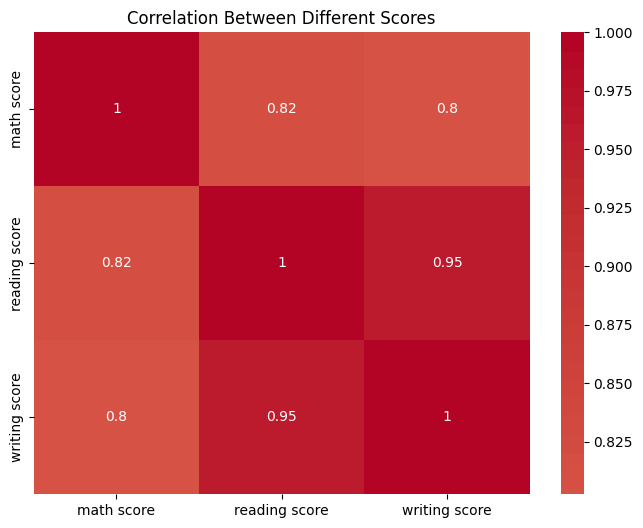

Key Observations:
Math-Reading correlation: 0.818
Math-Writing correlation: 0.803


In [24]:
# Cell 5: Correlation between scores
plt.figure(figsize=(8, 6))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Different Scores')
plt.show()

print("Key Observations:")
print(f"Math-Reading correlation: {df['math score'].corr(df['reading score']):.3f}")
print(f"Math-Writing correlation: {df['math score'].corr(df['writing score']):.3f}")

In [25]:
# Cell 6: Feature Engineering
df_encoded = df.copy()

# Encode categorical variables
le_dict = {}
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education',
                    'lunch', 'test preparation course']

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    print(f"Encoded: {col}")

# Create additional features (as per hint)
df_encoded['total_score'] = df_encoded['math score'] + df_encoded['reading score'] + df_encoded['writing score']
df_encoded['avg_other_scores'] = (df_encoded['reading score'] + df_encoded['writing score']) / 2

print("\nNew features created:")
print("- total_score: Sum of all scores")
print("- avg_other_scores: Average of reading and writing scores")

Encoded: gender
Encoded: race/ethnicity
Encoded: parental level of education
Encoded: lunch
Encoded: test preparation course

New features created:
- total_score: Sum of all scores
- avg_other_scores: Average of reading and writing scores


In [27]:
# Cell 7: Prepare Features for Prediction

# Select features (using reading and writing scores as predictors)
feature_columns = [
    'gender_encoded',
    'race/ethnicity_encoded',
    'parental level of education_encoded',
    'lunch_encoded',
    'test preparation course_encoded',
    'reading score',
    'writing score'
]

X = df_encoded[feature_columns]
y = df_encoded['math score']  # Target variable

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print("\nFeatures used for prediction:")
for i, col in enumerate(feature_columns):
    print(f"{i+1}. {col}")

Training set size: (800, 7)
Test set size: (200, 7)

Features used for prediction:
1. gender_encoded
2. race/ethnicity_encoded
3. parental level of education_encoded
4. lunch_encoded
5. test preparation course_encoded
6. reading score
7. writing score


In [28]:
# Cell 8: Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.3f}")
print(f"Accuracy: {lr_r2*100:.2f}%")

# Show sample predictions
print("\nSample Predictions vs Actual:")
sample_results = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': lr_pred[:10].round(2),
    'Difference': (y_test[:10].values - lr_pred[:10]).round(2)
})
print(sample_results)

LINEAR REGRESSION RESULTS
RMSE: 5.32
R² Score: 0.884
Accuracy: 88.38%

Sample Predictions vs Actual:
   Actual  Predicted  Difference
0      91      77.12       13.88
1      53      57.07       -4.07
2      80      79.36        0.64
3      74      77.15       -3.15
4      84      84.91       -0.91
5      81      79.86        1.14
6      69      64.42        4.58
7      54      52.47        1.53
8      87      74.61       12.39
9      51      50.01        0.99


In [29]:
# Cell 9: Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
rf_pred = rf_model.predict(X_test_scaled)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.3f}")
print(f"Accuracy: {rf_r2*100:.2f}%")

# Show sample predictions
print("\nSample Predictions vs Actual:")
sample_results = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': rf_pred[:10].round(2),
    'Difference': (y_test[:10].values - rf_pred[:10]).round(2)
})
print(sample_results)

RANDOM FOREST RESULTS
RMSE: 6.06
R² Score: 0.849
Accuracy: 84.91%

Sample Predictions vs Actual:
   Actual  Predicted  Difference
0      91      77.59       13.41
1      53      54.80       -1.80
2      80      76.16        3.84
3      74      77.13       -3.13
4      84      80.96        3.04
5      81      85.51       -4.51
6      69      65.41        3.59
7      54      54.42       -0.42
8      87      73.71       13.29
9      51      53.03       -2.03


In [30]:
# Cell 10: Gradient Boosting Model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Predict
gb_pred = gb_model.predict(X_test_scaled)

# Evaluate
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("="*50)
print("GRADIENT BOOSTING RESULTS")
print("="*50)
print(f"RMSE: {gb_rmse:.2f}")
print(f"R² Score: {gb_r2:.3f}")
print(f"Accuracy: {gb_r2*100:.2f}%")

# Show sample predictions
print("\nSample Predictions vs Actual:")
sample_results = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': gb_pred[:10].round(2),
    'Difference': (y_test[:10].values - gb_pred[:10]).round(2)
})
print(sample_results)

GRADIENT BOOSTING RESULTS
RMSE: 5.54
R² Score: 0.874
Accuracy: 87.38%

Sample Predictions vs Actual:
   Actual  Predicted  Difference
0      91      75.18       15.82
1      53      55.98       -2.98
2      80      78.66        1.34
3      74      76.70       -2.70
4      84      85.63       -1.63
5      81      78.92        2.08
6      69      65.69        3.31
7      54      53.61        0.39
8      87      75.27       11.73
9      51      49.84        1.16


In [31]:
# Cell 11: Model Comparison
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'R² Score': [lr_r2, rf_r2, gb_r2]
})

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(results.to_string(index=False))

# Find best model
best_model_idx = results['RMSE'].argmin()
best_model_name = results.iloc[best_model_idx]['Model']
best_rmse = results.iloc[best_model_idx]['RMSE']
best_r2 = results.iloc[best_model_idx]['R² Score']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   RMSE: {best_rmse:.2f}")
print(f"   R² Score: {best_r2:.3f}")
print(f"   Accuracy: {best_r2*100:.2f}%")

MODEL COMPARISON
            Model     RMSE  R² Score
Linear Regression 5.317451  0.883803
    Random Forest 6.060667  0.849051
Gradient Boosting 5.540894  0.873832

🏆 BEST MODEL: Linear Regression
   RMSE: 5.32
   R² Score: 0.884
   Accuracy: 88.38%


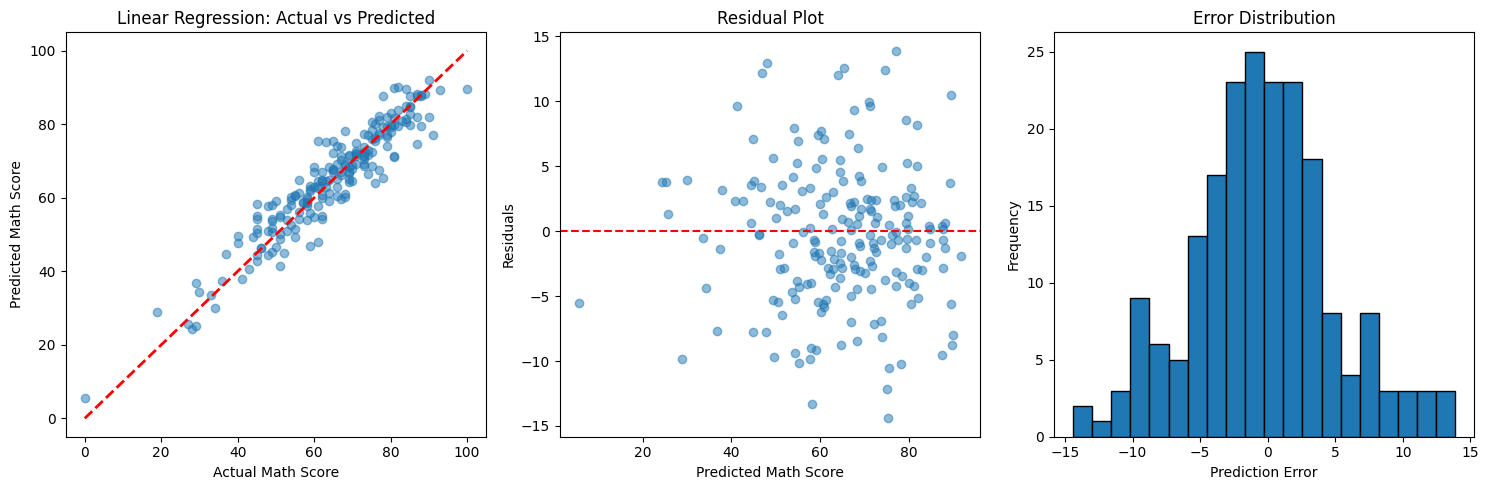

Average Prediction Error: ±5.32 points


In [32]:
# Cell 12: Visualize Best Model Predictions

# Get predictions from best model
if best_model_name == 'Linear Regression':
    best_pred = lr_pred
    best_model = lr_model
elif best_model_name == 'Random Forest':
    best_pred = rf_pred
    best_model = rf_model
else:
    best_pred = gb_pred
    best_model = gb_model

# Plot Actual vs Predicted
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, best_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title(f'{best_model_name}: Actual vs Predicted')

plt.subplot(1, 3, 2)
residuals = y_test - best_pred
plt.scatter(best_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Math Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 3, 3)
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Error Distribution')

plt.tight_layout()
plt.show()

print(f"Average Prediction Error: ±{best_rmse:.2f} points")

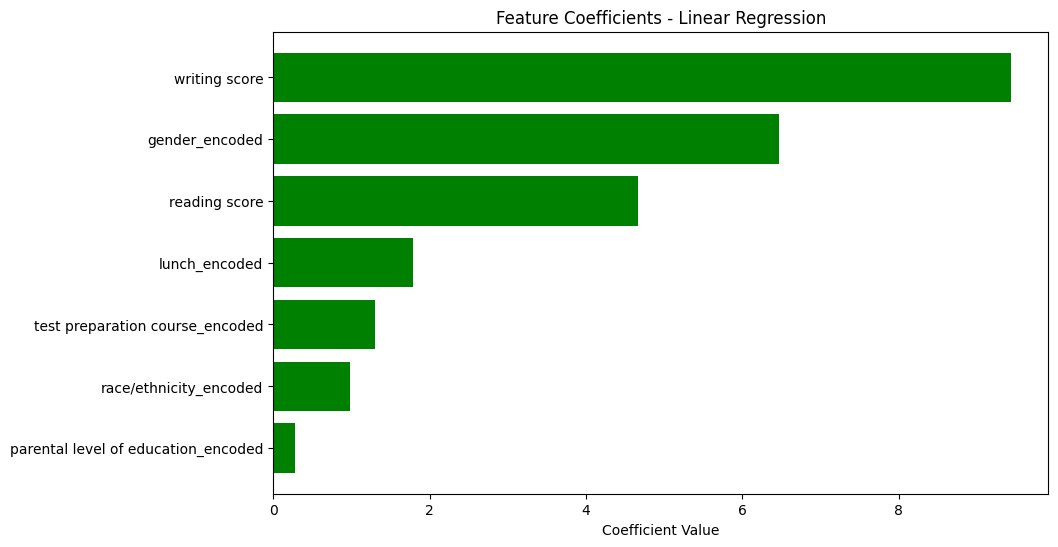

In [33]:
# Cell 13: Feature Importance Analysis
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importance = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.show()

    print("\nTop 3 Most Important Features:")
    for i in range(3):
        print(f"{i+1}. {feature_importance.iloc[i]['Feature']}: {feature_importance.iloc[i]['Importance']:.3f}")
else:
    # For linear regression, show coefficients
    coef_df = pd.DataFrame({
        'Feature': feature_columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', ascending=False)

    plt.figure(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
    plt.xlabel('Coefficient Value')
    plt.title('Feature Coefficients - Linear Regression')
    plt.gca().invert_yaxis()
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.show()

In [35]:
# Cell 14: PREDICTION FUNCTION - Use this to predict math scores

def predict_math_score(student_info, model, scaler, feature_columns, le_dict):
    """
    Predict math score for a new student

    Parameters:
    student_info: dict with keys:
        - gender: 'male' or 'female'
        - race/ethnicity: e.g., 'group C'
        - parental level of education: e.g., "bachelor's degree"
        - lunch: 'standard' or 'free/reduced'
        - test preparation course: 'none' or 'completed'
        - reading score: int (0-100)
        - writing score: int (0-100)
    """

    # Create dataframe
    input_df = pd.DataFrame([student_info])

    # Encode categorical variables
    for col in ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']:
        if col in input_df.columns:
            input_df[col + '_encoded'] = le_dict[col].transform(input_df[col])

    # Prepare features in correct order
    input_features = input_df[feature_columns]

    # Scale features
    input_scaled = scaler.transform(input_features)

    # Make prediction
    prediction = model.predict(input_scaled)[0]

    return round(prediction, 2)

# EXAMPLE 1: Student with good reading/writing scores
student1 = {
    'gender': 'female',
    'race/ethnicity': 'group C',
    'parental level of education': "bachelor's degree",
    'lunch': 'standard',
    'test preparation course': 'completed',
    'reading score': 85,
    'writing score': 82
}

# EXAMPLE 2: Student with average scores
student2 = {
    'gender': 'male',
    'race/ethnicity': 'group B',
    'parental level of education': 'some college',
    'lunch': 'standard',
    'test preparation course': 'none',
    'reading score': 65,
    'writing score': 60
}

# EXAMPLE 3: Student with low scores
student3 = {
    'gender': 'male',
    'race/ethnicity': 'group A',
    'parental level of education': 'high school',
    'lunch': 'free/reduced',
    'test preparation course': 'none',
    'reading score': 45,
    'writing score': 40
}

# Make predictions
print("="*70)
print(" MATH SCORE PREDICTIONS")
print("="*70)

print("\n STUDENT 1 (Well-prepared student):")
for key, value in student1.items():
    print(f"   {key}: {value}")
pred1 = predict_math_score(student1, best_model, scaler, feature_columns, le_dict)
print(f"    PREDICTED MATH SCORE: {pred1}")

print("\n🎓 STUDENT 2 (Average student):")
for key, value in student2.items():
    print(f"   {key}: {value}")
pred2 = predict_math_score(student2, best_model, scaler, feature_columns, le_dict)
print(f"    PREDICTED MATH SCORE: {pred2}")

print("\n🎓 STUDENT 3 (At-risk student):")
for key, value in student3.items():
    print(f"   {key}: {value}")
pred3 = predict_math_score(student3, best_model, scaler, feature_columns, le_dict)
print(f"    PREDICTED MATH SCORE: {pred3}")

 MATH SCORE PREDICTIONS

 STUDENT 1 (Well-prepared student):
   gender: female
   race/ethnicity: group C
   parental level of education: bachelor's degree
   lunch: standard
   test preparation course: completed
   reading score: 85
   writing score: 82
    PREDICTED MATH SCORE: 72.96

🎓 STUDENT 2 (Average student):
   gender: male
   race/ethnicity: group B
   parental level of education: some college
   lunch: standard
   test preparation course: none
   reading score: 65
   writing score: 60
    PREDICTED MATH SCORE: 68.04

🎓 STUDENT 3 (At-risk student):
   gender: male
   race/ethnicity: group A
   parental level of education: high school
   lunch: free/reduced
   test preparation course: none
   reading score: 45
   writing score: 40
    PREDICTED MATH SCORE: 44.16


In [36]:
# Cell 15: INTERACTIVE PREDICTION - Test with your own data

def get_student_input():
    """Get student information from user input"""
    print("\n" + "="*60)
    print("ENTER STUDENT INFORMATION FOR PREDICTION")
    print("="*60)

    # Get user input with defaults
    gender = input("Gender (male/female) [female]: ").strip() or "female"
    race = input("Race/Ethnicity (group A/B/C/D/E) [group C]: ").strip() or "group C"
    education = input("Parental Education (high school/some college/bachelor's degree/etc) [bachelor's degree]: ").strip() or "bachelor's degree"
    lunch = input("Lunch Type (standard/free/reduced) [standard]: ").strip() or "standard"
    test_prep = input("Test Preparation (completed/none) [completed]: ").strip() or "completed"

    try:
        reading = int(input("Reading Score (0-100) [85]: ") or "85")
        writing = int(input("Writing Score (0-100) [82]: ") or "82")
    except ValueError:
        print("Invalid input, using default values")
        reading, writing = 85, 82

    student = {
        'gender': gender.lower(),
        'race/ethnicity': race,
        'parental level of education': education.lower(),
        'lunch': lunch.lower(),
        'test preparation course': test_prep.lower(),
        'reading score': reading,
        'writing score': writing
    }

    return student


In [37]:
# Cell 16: Batch Predictions - Predict for multiple students at once

# Create a small dataset of students to predict
new_students = pd.DataFrame({
    'gender': ['female', 'male', 'female', 'male'],
    'race/ethnicity': ['group C', 'group B', 'group D', 'group A'],
    'parental level of education': ["bachelor's degree", "high school", "master's degree", "some college"],
    'lunch': ['standard', 'free/reduced', 'standard', 'free/reduced'],
    'test preparation course': ['completed', 'none', 'completed', 'none'],
    'reading score': [90, 55, 75, 40],
    'writing score': [88, 50, 78, 38]
})

print("="*60)
print("BATCH PREDICTIONS")
print("="*60)
print("\nStudent Data:")
print(new_students)

# Encode and predict for all
predictions = []
for idx, student in new_students.iterrows():
    pred = predict_math_score(student.to_dict(), best_model, scaler, feature_columns, le_dict)
    predictions.append(pred)

new_students['predicted_math_score'] = predictions
print("\n" + "="*60)
print("PREDICTION RESULTS:")
print("="*60)
print(new_students[['gender', 'reading score', 'writing score', 'predicted_math_score']].to_string(index=False))

BATCH PREDICTIONS

Student Data:
   gender race/ethnicity parental level of education         lunch  \
0  female        group C           bachelor's degree      standard   
1    male        group B                 high school  free/reduced   
2  female        group D             master's degree      standard   
3    male        group A                some college  free/reduced   

  test preparation course  reading score  writing score  
0               completed             90             88  
1                    none             55             50  
2               completed             75             78  
3                    none             40             38  

PREDICTION RESULTS:
gender  reading score  writing score  predicted_math_score
female             90             88                 78.33
  male             55             50                 54.50
female             75             78                 68.39
  male             40             38                 41.61


In [39]:
# Cell 17: Save model for deployment
import pickle

# Save all necessary components
model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': le_dict,
    'feature_columns': feature_columns
}

with open('math_score_predictor.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("Model saved as 'math_score_predictor.pkl'")
print("\nTo use this model in another application, load it with:")
print("""
import pickle
with open('math_score_predictor.pkl', 'rb') as f:
    artifacts = pickle.load(f)

model = artifacts['model']
scaler = artifacts['scaler']
le_dict = artifacts['label_encoders']
feature_columns = artifacts['feature_columns']
""")

Model saved as 'math_score_predictor.pkl'

To use this model in another application, load it with:

import pickle
with open('math_score_predictor.pkl', 'rb') as f:
    artifacts = pickle.load(f)
    
model = artifacts['model']
scaler = artifacts['scaler']
le_dict = artifacts['label_encoders']
feature_columns = artifacts['feature_columns']



In [40]:
# Cell 18: Save Model with Pickle
import pickle
import os

# Create a models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Save the complete model artifacts
model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': le_dict,
    'feature_columns': feature_columns,
    'model_name': best_model_name,
    'rmse': best_rmse,
    'r2_score': best_r2
}

# Save to pickle file
with open('models/student_performance_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("✅ Model saved successfully to 'models/student_performance_model.pkl'")
print(f"   File size: {os.path.getsize('models/student_performance_model.pkl') / 1024:.2f} KB")

✅ Model saved successfully to 'models/student_performance_model.pkl'
   File size: 2.08 KB


In [41]:
# Cell 19: Load and Test the Saved Model
with open('models/student_performance_model.pkl', 'rb') as f:
    loaded_artifacts = pickle.load(f)

# Extract components
loaded_model = loaded_artifacts['model']
loaded_scaler = loaded_artifacts['scaler']
loaded_encoders = loaded_artifacts['label_encoders']
loaded_features = loaded_artifacts['feature_columns']

print("✅ Model loaded successfully!")
print(f"Model Type: {loaded_artifacts['model_name']}")
print(f"RMSE: {loaded_artifacts['rmse']:.2f}")
print(f"R² Score: {loaded_artifacts['r2_score']:.3f}")

# Test prediction with loaded model
test_student = {
    'gender': 'female',
    'race/ethnicity': 'group C',
    'parental level of education': "bachelor's degree",
    'lunch': 'standard',
    'test preparation course': 'completed',
    'reading score': 85,
    'writing score': 82
}

# Use the same prediction function with loaded components
def predict_with_loaded(student_info, model, scaler, feature_cols, encoders):
    input_df = pd.DataFrame([student_info])

    for col in ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']:
        if col in input_df.columns:
            input_df[col + '_encoded'] = encoders[col].transform(input_df[col])

    input_features = input_df[feature_cols]
    input_scaled = scaler.transform(input_features)
    prediction = model.predict(input_scaled)[0]

    return round(prediction, 2)

pred = predict_with_loaded(test_student, loaded_model, loaded_scaler,
                          loaded_features, loaded_encoders)
print(f"\nTest Prediction: {pred}")

✅ Model loaded successfully!
Model Type: Linear Regression
RMSE: 5.32
R² Score: 0.884

Test Prediction: 72.96


In [42]:
# Cell 20: Save Individual Components
import joblib

# Save model separately
joblib.dump(best_model, 'models/best_model.joblib')
print("✅ Model saved: models/best_model.joblib")

# Save scaler separately
joblib.dump(scaler, 'models/scaler.joblib')
print("✅ Scaler saved: models/scaler.joblib")

# Save label encoders
joblib.dump(le_dict, 'models/label_encoders.joblib')
print("✅ Label encoders saved: models/label_encoders.joblib")

# Save feature columns
import json
with open('models/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print("✅ Feature columns saved: models/feature_columns.json")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'rmse': float(best_rmse),
    'r2_score': float(best_r2),
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("✅ Metadata saved: models/metadata.json")

✅ Model saved: models/best_model.joblib
✅ Scaler saved: models/scaler.joblib
✅ Label encoders saved: models/label_encoders.joblib
✅ Feature columns saved: models/feature_columns.json
✅ Metadata saved: models/metadata.json


In [43]:
# Cell 21: Load Individual Components
import joblib
import json

# Load model
loaded_model = joblib.load('models/best_model.joblib')
print("✅ Model loaded")

# Load scaler
loaded_scaler = joblib.load('models/scaler.joblib')
print("✅ Scaler loaded")

# Load encoders
loaded_encoders = joblib.load('models/label_encoders.joblib')
print("✅ Encoders loaded")

# Load feature columns
with open('models/feature_columns.json', 'r') as f:
    loaded_features = json.load(f)
print("✅ Feature columns loaded")

# Load metadata
with open('models/metadata.json', 'r') as f:
    metadata = json.load(f)
print(f"✅ Model: {metadata['model_name']}, R²: {metadata['r2_score']}")

✅ Model loaded
✅ Scaler loaded
✅ Encoders loaded
✅ Feature columns loaded
✅ Model: Linear Regression, R²: 0.8838026201112221


In [44]:
# Cell 22: Save Model Versions
from datetime import datetime

# Create versioned model directory
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
version_dir = f'models/version_{timestamp}'
os.makedirs(version_dir, exist_ok=True)

# Save with version info
model_version = {
    'model': best_model,
    'scaler': scaler,
    'encoders': le_dict,
    'features': feature_columns,
    'version': timestamp,
    'performance': {
        'rmse': best_rmse,
        'r2': best_r2,
        'model_name': best_model_name
    }
}

with open(f'{version_dir}/model_v{timestamp}.pkl', 'wb') as f:
    pickle.dump(model_version, f)

# Also save as CSV for easy viewing
performance_df = pd.DataFrame([{
    'version': timestamp,
    'model': best_model_name,
    'rmse': best_rmse,
    'r2': best_r2
}])
performance_df.to_csv(f'{version_dir}/performance.csv', index=False)

print(f"✅ Model version {timestamp} saved to {version_dir}")

✅ Model version 20260311_102101 saved to models/version_20260311_102101


In [45]:
# Cell 23: Create Deployable Package

# Create a complete prediction package
class StudentPerformancePredictor:
    def __init__(self, model_path=None):
        if model_path:
            self.load(model_path)

    def train(self, X, y):
        """Train the model"""
        self.model = GradientBoostingRegressor(n_estimators=100, random_state=42)
        self.model.fit(X, y)
        return self

    def save(self, filepath):
        """Save the complete predictor"""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'model': self.model,
                'scaler': self.scaler if hasattr(self, 'scaler') else None,
                'encoders': self.encoders if hasattr(self, 'encoders') else None,
                'features': self.features if hasattr(self, 'features') else None
            }, f)

    def load(self, filepath):
        """Load the predictor"""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
            self.model = data['model']
            self.scaler = data['scaler']
            self.encoders = data['encoders']
            self.features = data['features']
        return self

    def predict(self, student_data):
        """Predict math score for a single student"""
        input_df = pd.DataFrame([student_data])

        # Encode categorical variables
        for col in ['gender', 'race/ethnicity', 'parental level of education',
                    'lunch', 'test preparation course']:
            if col in input_df.columns and col in self.encoders:
                input_df[col + '_encoded'] = self.encoders[col].transform(input_df[col])

        # Prepare features
        input_features = input_df[self.features]

        # Scale if scaler exists
        if self.scaler:
            input_features = self.scaler.transform(input_features)

        # Predict
        prediction = self.model.predict(input_features)[0]
        return round(prediction, 2)

    def predict_batch(self, students_df):
        """Predict for multiple students"""
        predictions = []
        for _, student in students_df.iterrows():
            pred = self.predict(student.to_dict())
            predictions.append(pred)
        return predictions

# Create and save the predictor
predictor = StudentPerformancePredictor()
predictor.model = best_model
predictor.scaler = scaler
predictor.encoders = le_dict
predictor.features = feature_columns

# Save the complete predictor
predictor.save('models/complete_predictor.pkl')
print("✅ Complete predictor saved to 'models/complete_predictor.pkl'")

# Test the loaded predictor
loaded_predictor = StudentPerformancePredictor().load('models/complete_predictor.pkl')
test_pred = loaded_predictor.predict(test_student)
print(f"Test prediction with loaded predictor: {test_pred}")

✅ Complete predictor saved to 'models/complete_predictor.pkl'
Test prediction with loaded predictor: 72.96
